## Gathering the Information

This notebook processes network traffic data captured in `.pcapng` format. The files used represent:

*   **`normal.pcapng`**: Network traffic under normal operating conditions.
*   **`scan.pcapng`**: Network traffic captured during a port scanning attack.

These captures were obtained using Wireshark on Kali Linux, targeting traffic from a Metasploitable machine.

In [1]:
%pip install nfstream

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.0/195.0 kB 14.8 MB/s eta 0:00:00


In [2]:
from nfstream import NFStreamer
import pandas as pd

In [3]:
""" Coverting the 'Normal.pcapng' file into the csv format using the nfstreamer """
normal = NFStreamer(source = "normal.pcapng").to_pandas()
normal["label"] = 0

In [4]:
""" Coverting the 'scan.pcapng' file into the csv format using the nfstreamer """
scan = NFStreamer(source = "scan.pcapng").to_pandas()
scan["label"] = 1

/usr/local/lib/python3.12/dist-packages/nfstream/streamer.py:625: DtypeWarning: Columns (33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [5]:
normal_df = normal[normal["label"] == 0]
scan_df = scan[scan["label"] == 1]
scan_sample = scan_df.sample(n = len(normal_df),random_state = 42)

In [6]:
df = pd.concat([normal_df,scan_sample],ignore_index = True)

In [7]:
df

,id,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,...,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,label
0,0,0,192.168.55.1,9c:65:ee:48:4e:7f,9c:65:ee,0,224.0.0.1,01:00:5e:00:00:01,01:00:5e,0,...,IGMP,Network,0,6,NaN,NaN,NaN,NaN,NaN,0
1,1,0,192.168.56.1,9c:65:ee:48:4e:7f,9c:65:ee,0,224.0.0.1,01:00:5e:00:00:01,01:00:5e,0,...,IGMP,Network,0,6,NaN,NaN,NaN,NaN,NaN,0
2,2,0,192.168.55.103,18:93:41:b4:2e:7c,18:93:41,0,239.255.255.250,01:00:5e:7f:ff:fa,01:00:5e,0,...,IGMP,Network,0,6,NaN,NaN,NaN,NaN,NaN,0
3,3,0,192.168.55.106,08:00:27:67:4f:ac,08:00:27,68,255.255.255.255,ff:ff:ff:ff:ff:ff,ff:ff:ff,67,...,DHCP,Network,0,6,NaN,"1,28,2,3,15,6,12,42",NaN,NaN,NaN,0
4,4,0,192.168.55.1,9c:65:ee:48:4e:7f,9c:65:ee,0,224.0.0.1,01:00:5e:00:00:01,01:00:5e,0,...,IGMP,Network,0,6,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,38854,0,192.168.55.105,08:00:27:51:10:de,08:00:27,64195,192.168.55.106,08:00:27:67:4f:ac,08:00:27,40561,...,Unknown,Unspecified,0,0,NaN,NaN,NaN,NaN,NaN,1
112,64348,0,192.168.55.105,08:00:27:51:10:de,08:00:27,64195,192.168.55.106,08:00:27:67:4f:ac,08:00:27,18520,...,Unknown,Unspecified,0,0,NaN,NaN,NaN,NaN,NaN,1
113,56300,0,192.168.55.105,08:00:27:51:10:de,08:00:27,64195,192.168.55.106,08:00:27:67:4f:ac,08:00:27,59460,...,Unknown,Unspecified,0,0,NaN,NaN,NaN,NaN,NaN,1
114,9803,0,192.168.55.105,08:00:27:51:10:de,08:00:27,64195,192.168.55.106,08:00:27:67:4f:ac,08:00:27,31891,...,Unknown,Unspecified,0,0,NaN,NaN,NaN,NaN,NaN,1


In [8]:
df.shape

(116, 39)

In [9]:
df.columns

Index(['id', 'expiration_id', 'src_ip', 'src_mac', 'src_oui', 'src_port',
       'dst_ip', 'dst_mac', 'dst_oui', 'dst_port', 'protocol', 'ip_version',
       'vlan_id', 'tunnel_id', 'bidirectional_first_seen_ms',
       'bidirectional_last_seen_ms', 'bidirectional_duration_ms',
       'bidirectional_packets', 'bidirectional_bytes', 'src2dst_first_seen_ms',
       'src2dst_last_seen_ms', 'src2dst_duration_ms', 'src2dst_packets',
       'src2dst_bytes', 'dst2src_first_seen_ms', 'dst2src_last_seen_ms',
       'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes',
       'application_name', 'application_category_name',
       'application_is_guessed', 'application_confidence',
       'requested_server_name', 'client_fingerprint', 'server_fingerprint',
       'user_agent', 'content_type', 'label'],
      dtype='object')

## EDA plots

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

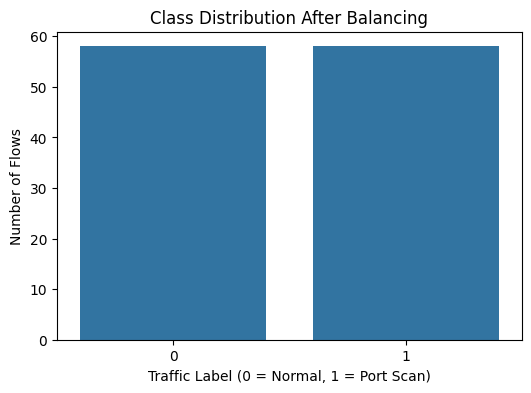

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="label")

plt.title("Class Distribution After Balancing")
plt.xlabel("Traffic Label (0 = Normal, 1 = Port Scan)")
plt.ylabel("Number of Flows")
plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

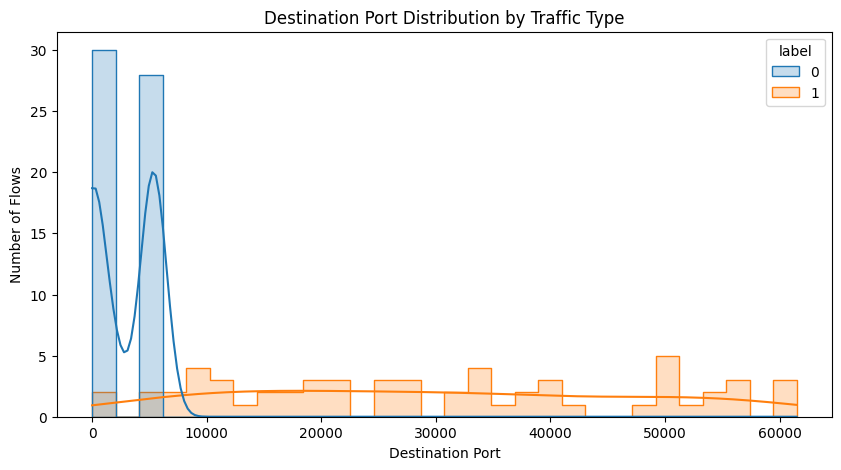

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="dst_port",
    hue="label",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Destination Port Distribution by Traffic Type")
plt.xlabel("Destination Port")
plt.savefig("dst_port_distribution.png", dpi=300, bbox_inches="tight")
plt.ylabel("Number of Flows")
plt.show()

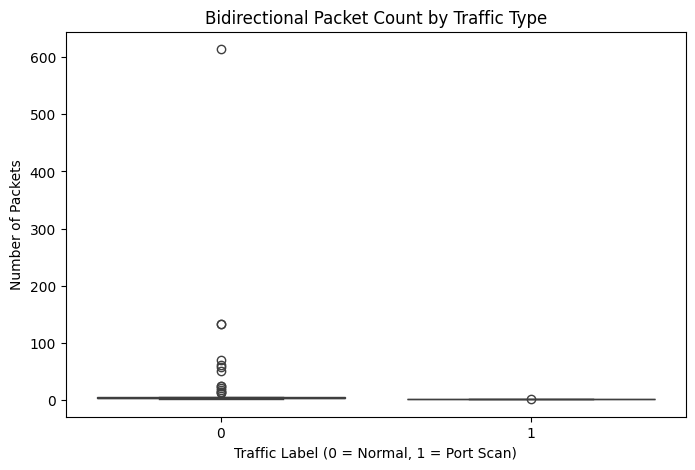

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="bidirectional_packets"
)

plt.title("Bidirectional Packet Count by Traffic Type")
plt.xlabel("Traffic Label (0 = Normal, 1 = Port Scan)")
plt.ylabel("Number of Packets")
plt.savefig("packet_count_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

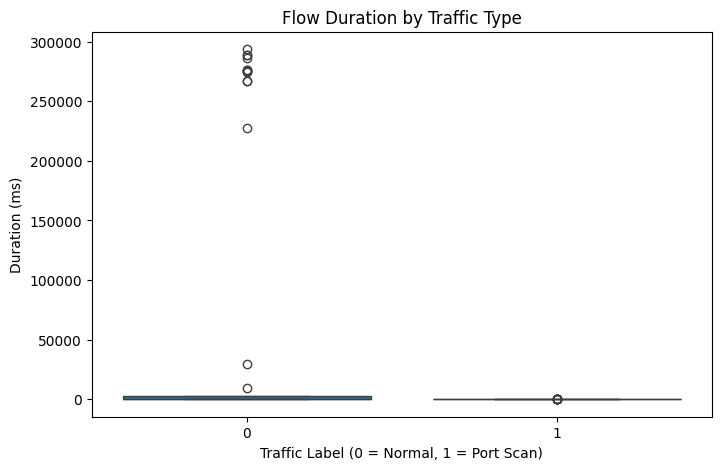

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="bidirectional_duration_ms"
)

plt.title("Flow Duration by Traffic Type")
plt.xlabel("Traffic Label (0 = Normal, 1 = Port Scan)")
plt.ylabel("Duration (ms)")
plt.show()

## Data Preprocessing

In [15]:
drop_cols = [
    "expiration_id",
    "src_oui",
    "dst_oui",
    "vlan_id",
    "tunnel_id",
    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",
    "src2dst_first_seen_ms",
    "src2dst_last_seen_ms",
    "dst2src_first_seen_ms",
    "dst2src_last_seen_ms",
    "application_name",
    "application_category_name",
    "requested_server_name",
    "client_fingerprint",
    "server_fingerprint",
    "user_agent",
    "content_type"
]

df = df.drop(columns=drop_cols, errors="ignore")
print(df.columns.tolist())

['id', 'src_ip', 'src_mac', 'src_port', 'dst_ip', 'dst_mac', 'dst_port', 'protocol', 'ip_version', 'bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_duration_ms', 'src2dst_packets', 'src2dst_bytes', 'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes', 'application_is_guessed', 'application_confidence', 'label']


In [16]:
df.columns

Index(['id', 'src_ip', 'src_mac', 'src_port', 'dst_ip', 'dst_mac', 'dst_port',
       'protocol', 'ip_version', 'bidirectional_duration_ms',
       'bidirectional_packets', 'bidirectional_bytes', 'src2dst_duration_ms',
       'src2dst_packets', 'src2dst_bytes', 'dst2src_duration_ms',
       'dst2src_packets', 'dst2src_bytes', 'application_is_guessed',
       'application_confidence', 'label'],
      dtype='object')

In [17]:
print(df.isnull().sum())

id                           0
src_ip                       0
src_mac                      0
src_port                     0
dst_ip                       0
dst_mac                      0
dst_port                     0
protocol                     0
ip_version                   0
bidirectional_duration_ms    0
bidirectional_packets        0
bidirectional_bytes          0
src2dst_duration_ms          0
src2dst_packets              0
src2dst_bytes                0
dst2src_duration_ms          0
dst2src_packets              0
dst2src_bytes                0
application_is_guessed       0
application_confidence       0
label                        0
dtype: int64


In [18]:
print(df.nunique())

id                           116
src_ip                        13
src_mac                        6
src_port                      27
dst_ip                        12
dst_mac                       12
dst_port                      67
protocol                       5
ip_version                     2
bidirectional_duration_ms     32
bidirectional_packets         18
bidirectional_bytes           34
src2dst_duration_ms           31
src2dst_packets               17
src2dst_bytes                 33
dst2src_duration_ms            4
dst2src_packets                5
dst2src_bytes                  5
application_is_guessed         1
application_confidence         2
label                          2
dtype: int64


In [19]:
print(df['label'].value_counts())

label
0    58
1    58
Name: count, dtype: int64


In [20]:
leakage_cols = ["src_ip", "dst_ip", "src_mac", "dst_mac"]
df = df.drop(columns=[col for col in leakage_cols if col in df.columns])
print(df.columns.tolist())

['id', 'src_port', 'dst_port', 'protocol', 'ip_version', 'bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_duration_ms', 'src2dst_packets', 'src2dst_bytes', 'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes', 'application_is_guessed', 'application_confidence', 'label']


In [21]:
df

,id,src_port,dst_port,protocol,ip_version,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_duration_ms,src2dst_packets,src2dst_bytes,dst2src_duration_ms,dst2src_packets,dst2src_bytes,application_is_guessed,application_confidence,label
0,0,0,0,2,4,0,3,180,0,3,180,0,0,0,0,6,0
1,1,0,0,2,4,99,3,180,99,3,180,0,0,0,0,6,0
2,2,0,0,2,4,0,1,60,0,1,60,0,0,0,0,6,0
3,3,68,67,17,4,0,1,342,0,1,342,0,0,0,0,6,0
4,4,0,0,2,4,0,3,180,0,3,180,0,0,0,0,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,38854,64195,40561,6,4,0,2,118,0,1,58,0,1,60,0,0,1
112,64348,64195,18520,6,4,0,2,118,0,1,58,0,1,60,0,0,1
113,56300,64195,59460,6,4,0,2,118,0,1,58,0,1,60,0,0,1
114,9803,64195,31891,6,4,0,2,118,0,1,58,0,1,60,0,0,1


In [22]:
"""All the Unique Values inisde the dataframe"""
df['protocol'].unique()

array([ 2, 17,  1, 58,  6])

In [23]:
df['protocol'].dtype

dtype('int64')

## Training the model

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [25]:
X = df.drop("label",axis = 1)
y = df['label']

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Using Logisitic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)


In [29]:
print(y_pred_lr)

[1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 1 1 1 1 1 0]


### Evaluating the model - Logistic Regression

In [30]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0


In [31]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        10

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



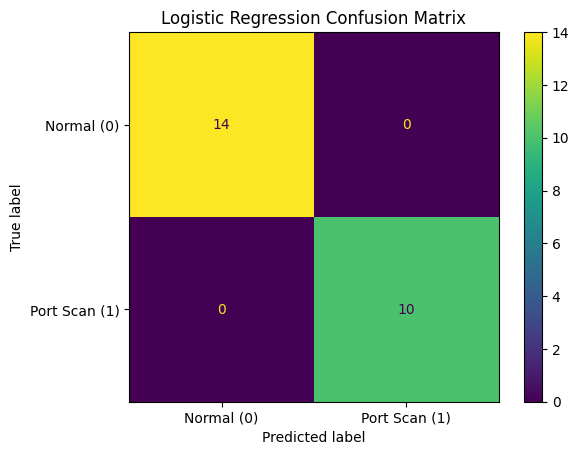

In [32]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Normal (0)", "Port Scan (1)"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.savefig("lr_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Using Random Forest Classifier

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=cv,
    scoring="f1"
)
print("Cross-validation F1 scores:", scores)
print("Mean F1 score:", scores.mean())
print("Standard deviation:", scores.std())

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

Cross-validation F1 scores: [1.         1.         0.91666667 1.         1.        ]
Mean F1 score: 0.9833333333333332
Standard deviation: 0.03333333333333335


In [34]:
print(y_pred_rf)

[1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 1 1 1 1 1 0]


### Evaluating the model - Random Forest Classifier

In [35]:
""" Finiding the Accuracy """
accuracy = accuracy_score(y_test,y_pred_rf)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


In [36]:
""" Precision, Recall and F1-Score"""
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        10

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



In [37]:
""" Confusion Matrix"""
cm_rf = confusion_matrix(y_test,y_pred_rf)
print(cm_rf)

[[14  0]
 [ 0 10]]


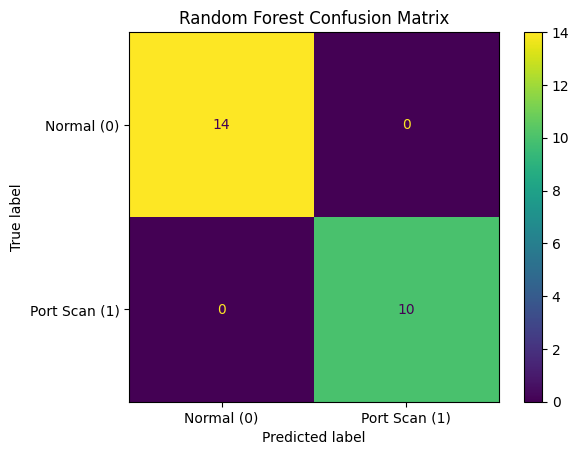

In [38]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Normal (0)", "Port Scan (1)"]
)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.savefig("rf_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Saving the .csv file

In [39]:
predictions_df = pd.DataFrame({
    "actual_label": y_test.values,
    "random_forest_prediction": y_pred_rf,
    "logistic_regression_prediction": y_pred_lr
})

predictions_df.to_csv("predictions_comparison.csv", index=False)